<a href="https://colab.research.google.com/github/zynoozyno6-rgb/DL-assaingment-1/blob/main/ML_ASSIGNMENT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAME :زينب الجنيد

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()

X = iris.data

y = (iris.target == 1).astype(int)   # 1 = Versicolor, 0 = Others

In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("Class distribution:")

print("Versicolor =", np.sum(y == 1))
print("Others =", np.sum(y == 0))

Number of samples: 150
Number of features: 4
Class distribution:
Versicolor = 50
Others = 100


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression())
])

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [9]:
print("Cross Validation Accuracy:")
print(scores)

print("\nMean Accuracy:")
print(scores.mean())

Cross Validation Accuracy:
[0.70833333 0.75       0.75       0.83333333 0.58333333]

Mean Accuracy:
0.7250000000000001


In [10]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [11]:
y_pred = pipe.predict(X_test)

In [12]:
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7


In [13]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

In [14]:
def precision(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))

    if TP + FP == 0:
        return 0

    return TP / (TP + FP)

In [15]:
def recall(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    if TP + FN == 0:
        return 0

    return TP / (TP + FN)

In [16]:
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)

    if p + r == 0:
        return 0

    return 2 * (p * r) / (p + r)

In [17]:
print("Accuracy :", accuracy(y_test, y_pred))
print("Precision:", precision(y_test, y_pred))
print("Recall   :", recall(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7
Precision: 0.6
Recall   : 0.3
F1 Score : 0.4


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80        20
           1       0.60      0.30      0.40        10

    accuracy                           0.70        30
   macro avg       0.66      0.60      0.60        30
weighted avg       0.68      0.70      0.67        30



In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score as sklearn_f1

print("========== NumPy Implementation ==========")
print(f"Accuracy : {accuracy(y_test, y_pred):.4f}")
print(f"Precision: {precision(y_test, y_pred):.4f}")
print(f"Recall   : {recall(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\n========== Scikit-Learn ==========")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {sklearn_f1(y_test, y_pred):.4f}")

========== NumPy Implementation ==========
Accuracy : 0.7000
Precision: 0.6000
Recall   : 0.3000
F1 Score : 0.4000

========== Scikit-Learn ==========
Accuracy : 0.7000
Precision: 0.6000
Recall   : 0.3000
F1 Score : 0.4000


In [20]:
from sklearn.model_selection import validation_curve

In [21]:
param_range = np.logspace(-3, 3, 7)

print(param_range)

[1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]


In [22]:
train_scores, validation_scores = validation_curve(
    estimator=LogisticRegression(max_iter=1000),
    X=X_train,
    y=y_train,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

In [23]:
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

print(train_mean)
print(validation_mean)

[0.66666667 0.66666667 0.65833333 0.75416667 0.74583333 0.75
 0.75      ]
[0.66666667 0.66666667 0.63333333 0.725      0.725      0.73333333
 0.73333333]


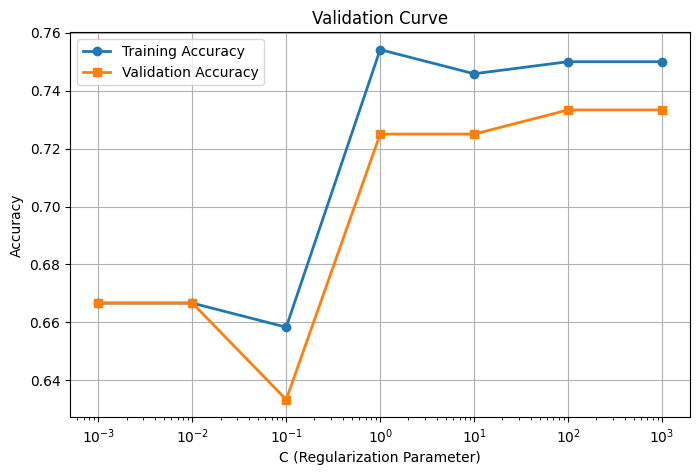

In [24]:
plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean,
         marker='o',
         linewidth=2,
         label='Training Accuracy')

plt.plot(param_range, validation_mean,
         marker='s',
         linewidth=2,
         label='Validation Accuracy')

plt.xscale("log")

plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Accuracy")
plt.title("Validation Curve")

plt.grid(True)
plt.legend()

plt.show()

The validation curve shows how the logistic regression model performs for different values of the regularization parameter C. Very small values of C may lead to underfitting, while very large values can increase the risk of overfitting. The optimal value of C is where the validation accuracy reaches its highest level.

In [25]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [26]:
y_prob = pipe.predict_proba(X_test)[:,1]

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [28]:
auc = roc_auc_score(y_test, y_prob)

print("AUC =", auc)

AUC = 0.77


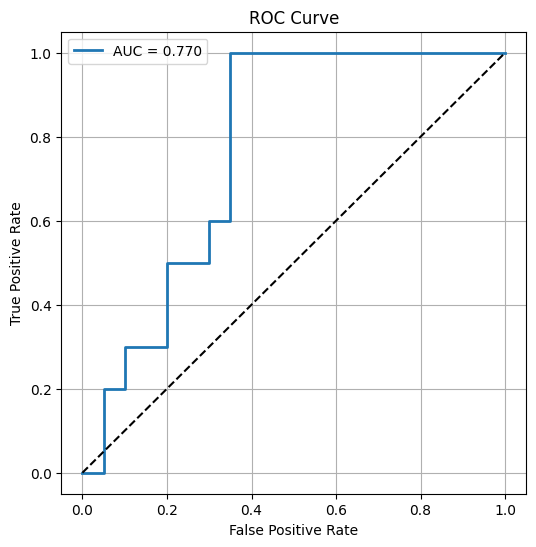

In [29]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

The ROC curve illustrates the trade-off between the True Positive Rate and the False Positive Rate. The AUC value summarizes the classifier's ability to distinguish between the two classes. An AUC closer to 1 indicates excellent classification performance.



For each of the following real-world scenarios, state whether it is best suited for supervised learning, unsupervised learning, or reinforcement learning. Justify your answer based on the problem constraints (type of feedback, availability of labels, etc.). : Predicting the price of a used car given its mileage, age, and brand.

# **supervised learning (regerssion) becouse it is prdict the countious value numper **
A chess program that learns to improve its play by playing against itself.

# reinforcement learing becouse the program not basesd to labeled data just reaction with envaiorment th maxmaize itrative reword
Grouping customers into segments based on purchasing behaviour without any predefined labels.

# unsupervised learnin becouse use unlabel data with out knowlage
Detecting whether an email is spam or not from a labelled collection of emails.

# supervised learning becouse it predict discrate categories

Explain the concept of inductive bias


# ا**لانحياز الاستقرائي هو مجموعة من الافتراضات التي تستخدمها خوارزميات تعلم الالة للتنبؤ بالمخرجات

and why it is necessary for a learning algorithm to generalise beyond its training data.
# وهو مهم جدا للتعميم لانه بدونه يعبر النموذج عن الحفظ وليس القدرة على النجاح مع بيانات جديدة **


Use the No-Free-Lunch theorem to argue why no single inductive bias works for all problems.

# تنص هذه النظرية على انه لايوجد خوارزمية خارقة للعمل مع كل المشاكل قد تكون احدى الخوارزميات ممتازة لحل نوع معين من المشاكل لكنها قد تكون سيئة مع مشاكل اخرى ويجب مطابقة الانجياز الخاص بالمشكلة مع الانخياز للخوارزمية للوصول الى نتائج ممتازة